In [ ]:
import sys

In [3]:
sys.path.append('/scratch/radjoe/Projects/Experiments/MedSAM2')

In [ ]:
import gc
import json
import logging
import math
import os
import time
from collections import OrderedDict
from dataclasses import dataclass, field
from typing import Any, Dict, List, Mapping, Optional

import numpy as np

import torch
import torch.distributed as dist
import torch.nn as nn
from hydra.utils import instantiate
from iopath.common.file_io import g_pathmgr
import torch.nn.functional as F


In [ ]:
label = np.load('/scratch_net/ken/radjoe/BraTS/Validation/labels_UNN/BraTS-GLI-00016-000-lbl.npy')

: 

In [13]:
label[1, :,:, 80].shape

(192, 224)

In [14]:
import matplotlib.pyplot as plt

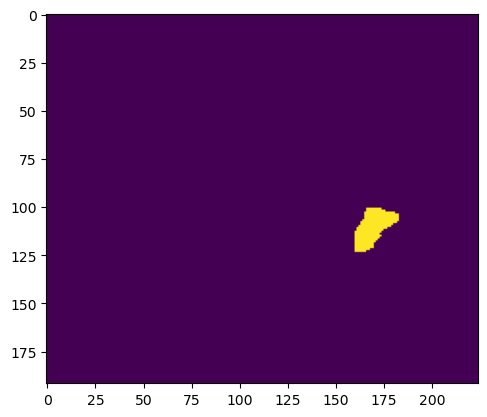

In [20]:
plt.imshow(label[1, :,:, 90])

In [7]:
np.unique(label[1])

array([0., 1.], dtype=float32)

In [8]:
np.unique(label[2])

array([0., 1.], dtype=float32)

In [10]:
np.unique(label[3])

array([0., 1.], dtype=float32)

In [41]:
def sigmoid_focal_loss(
    inputs,
    targets,
    # num_objects,
    alpha: float = 0.25,
    gamma: float = 2,
    loss_on_multimask=False,
):
    """
    Loss used in RetinaNet for dense detection: https://arxiv.org/abs/1708.02002.
    Args:
        inputs: A float tensor of arbitrary shape.
                The predictions for each example.
        targets: A float tensor with the same shape as inputs. Stores the binary
                 classification label for each element in inputs
                (0 for the negative class and 1 for the positive class).
        num_objects: Number of objects in the batch
        alpha: (optional) Weighting factor in range (0,1) to balance
                positive vs negative examples. Default = -1 (no weighting).
        gamma: Exponent of the modulating factor (1 - p_t) to
               balance easy vs hard examples.
        loss_on_multimask: True if multimask prediction is enabled
    Returns:
        focal loss tensor
    """
    prob = inputs.sigmoid()
    ce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction="none")
    print(ce_loss.shape)
    p_t = prob * targets + (1 - prob) * (1 - targets)
    loss = ce_loss * ((1 - p_t) ** gamma)

    if alpha >= 0:
        alpha_t = alpha * targets + (1 - alpha) * (1 - targets)
        loss = alpha_t * loss

    return loss.mean()

In [46]:
y_pred = torch.zeros(1,3,512,512)
y = torch.ones(1, 3, 512, 512)

In [47]:
loss = sigmoid_focal_loss(y, y_pred)

torch.Size([1, 3, 512, 512])


In [48]:
loss

tensor(0.5264)